In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8500999999977649 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.6                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                    

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [5]:
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [6]:
school_name = "P.S. 034 Franklin D. Roosevelt"

school_df = df[df["School Name"] == school_name].copy()
print(school_df.head())
print("Number of rows for selected school:", len(school_df))

      School DBN                     School Name School Level  \
0         01M034  P.S. 034 Franklin D. Roosevelt          K-8   
1         01M034  P.S. 034 Franklin D. Roosevelt          K-8   
2         01M034  P.S. 034 Franklin D. Roosevelt          K-8   
19478     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
19479     01M034  P.S. 034 Franklin D. Roosevelt          K-8   

              Regents Exam  Year  Total Tested Mean Score  \
0      Common Core Algebra  2017             4          s   
1       Living Environment  2015            16       77.9   
2       Living Environment  2016             9         74   
19478  Common Core Algebra  2017             3          s   
19479  Common Core Algebra  2017             1          s   

      Number Scoring Below 65 Percent Scoring Below 65  \
0                           s                        s   
1                           1                      6.3   
2                           1                     11.1   
19478     

In [7]:
score_col = "Percent Scoring 65 or Above"
print("Selected performance measure:", score_col)

Selected performance measure: Percent Scoring 65 or Above


In [8]:
exam_name = "Living Environment"

# Filter data for the selected exam
exam_df = df[df["Regents Exam"] == exam_name].copy()

# Selected school for that exam
school_exam_df = exam_df[exam_df["School Name"] == school_name].copy()

print("Selected school exam records:")
print(school_exam_df[["School Name", "Year", "Regents Exam", score_col]])

Selected school exam records:
                           School Name  Year        Regents Exam  \
1       P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
2       P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
19480   P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
19481   P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
54236   P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
54237   P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
54238   P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
54239   P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
54240   P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
102881  P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
102882  P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
102883  P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
102884  P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
139886  P.S. 034 F

In [11]:
# Cleaning task: replace suppressed/non-applicable values and convert to numeric
exam_df[score_col] = exam_df[score_col].replace(["s", "na", "NA", "S"], np.nan)
exam_df[score_col] = pd.to_numeric(exam_df[score_col], errors="coerce")

exam_df["Mean Score"] = exam_df["Mean Score"].replace(["s", "na", "NA", "S"], np.nan)
exam_df["Mean Score"] = pd.to_numeric(exam_df["Mean Score"], errors="coerce")

exam_df["Total Tested"] = exam_df["Total Tested"].replace(["s", "na", "NA", "S"], np.nan)
exam_df["Total Tested"] = pd.to_numeric(exam_df["Total Tested"], errors="coerce")

# Drop rows where chosen score is missing
exam_clean = exam_df.dropna(subset=[score_col]).copy()

# Recreate selected school subset after cleaning
school_exam_clean = exam_clean[exam_clean["School Name"] == school_name].copy()

print("Cleaned dataset shape:", exam_clean.shape)
print(school_exam_clean[["School Name", "Year", "Regents Exam", score_col]])

<class 'NameError'>: name 'np' is not defined

In [13]:
import numpy as np  

# Cleaning task: replace suppressed/non-applicable values and convert to numeric
exam_df[score_col] = exam_df[score_col].replace(["s", "na", "NA", "S"], np.nan)
exam_df[score_col] = pd.to_numeric(exam_df[score_col], errors="coerce")

exam_df["Mean Score"] = exam_df["Mean Score"].replace(["s", "na", "NA", "S"], np.nan)
exam_df["Mean Score"] = pd.to_numeric(exam_df["Mean Score"], errors="coerce")

exam_df["Total Tested"] = exam_df["Total Tested"].replace(["s", "na", "NA", "S"], np.nan)
exam_df["Total Tested"] = pd.to_numeric(exam_df["Total Tested"], errors="coerce")

# Drop rows where chosen score is missing
exam_clean = exam_df.dropna(subset=[score_col]).copy()

# Recreate selected school subset after cleaning
school_exam_clean = exam_clean[exam_clean["School Name"] == school_name].copy()

print("Cleaned dataset shape:", exam_clean.shape)
print(school_exam_clean[["School Name", "Year", "Regents Exam", score_col]])

Cleaned dataset shape: (18243, 15)
                           School Name  Year        Regents Exam  \
1       P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
2       P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
19480   P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
19481   P.S. 034 Franklin D. Roosevelt  2016  Living Environment   
54237   P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
102881  P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
102882  P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
139886  P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
139888  P.S. 034 Franklin D. Roosevelt  2015  Living Environment   
139892  P.S. 034 Franklin D. Roosevelt  2016  Living Environment   

        Percent Scoring 65 or Above  
1                              93.8  
2                              88.9  
19480                          93.8  
19481                          88.9  
54237                     

In [14]:
dataset_stats = exam_clean[score_col].describe()
print("Descriptive statistics for all schools (Living Environment):")
print(dataset_stats)

Descriptive statistics for all schools (Living Environment):
count    18243.000000
mean        65.715233
std         25.217209
min          0.000000
25%         47.300000
50%         66.700000
75%         88.000000
max        100.000000
Name: Percent Scoring 65 or Above, dtype: float64


In [15]:
school_stats = school_exam_clean[score_col].describe()
print("Descriptive statistics for selected school:")
print(school_stats)

Descriptive statistics for selected school:
count     10.000000
mean      93.760000
std        6.110319
min       83.300000
25%       88.900000
50%       93.800000
75%      100.000000
max      100.000000
Name: Percent Scoring 65 or Above, dtype: float64


In [16]:
school_avg = school_exam_clean[score_col].mean()
dataset_avg = exam_clean[score_col].mean()
school_median = school_exam_clean[score_col].median()
dataset_median = exam_clean[score_col].median()

print(f"{school_name} average {score_col}: {school_avg:.2f}")
print(f"All schools average {score_col}: {dataset_avg:.2f}")
print(f"{school_name} median {score_col}: {school_median:.2f}")
print(f"All schools median {score_col}: {dataset_median:.2f}")

P.S. 034 Franklin D. Roosevelt average Percent Scoring 65 or Above: 93.76
All schools average Percent Scoring 65 or Above: 65.72
P.S. 034 Franklin D. Roosevelt median Percent Scoring 65 or Above: 93.80
All schools median Percent Scoring 65 or Above: 66.70


In [17]:
year_comparison = exam_clean.groupby("Year")[score_col].mean().reset_index(name="Dataset Average")
school_year_comparison = school_exam_clean.groupby("Year")[score_col].mean().reset_index(name="School Average")

comparison_df = pd.merge(year_comparison, school_year_comparison, on="Year", how="left")
print(comparison_df)

   Year  Dataset Average  School Average
0  2015        65.970257       94.257143
1  2016        67.486449       92.600000
2  2017        63.806369             NaN


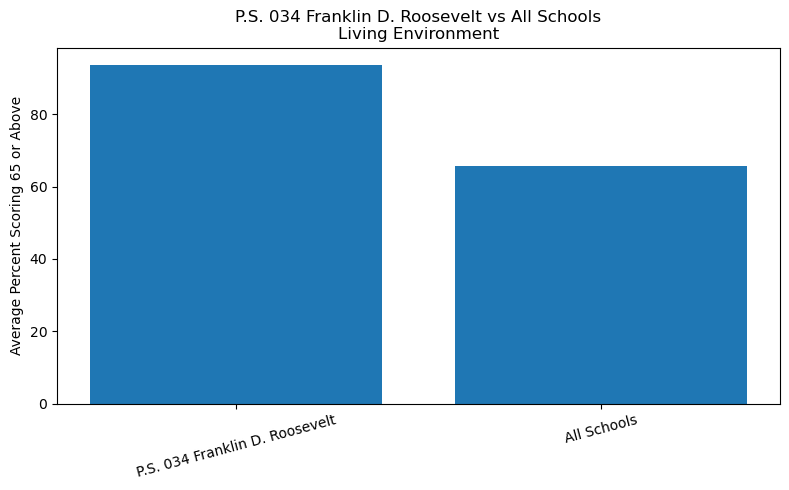

In [19]:
import matplotlib.pyplot as plt

comparison_summary = pd.DataFrame({
    "Group": [school_name, "All Schools"],
    "Average Percent Scoring 65 or Above": [school_avg, dataset_avg]
})

plt.figure(figsize=(8, 5))
plt.bar(comparison_summary["Group"], comparison_summary["Average Percent Scoring 65 or Above"])
plt.ylabel("Average Percent Scoring 65 or Above")
plt.title(f"{school_name} vs All Schools\n{exam_name}")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

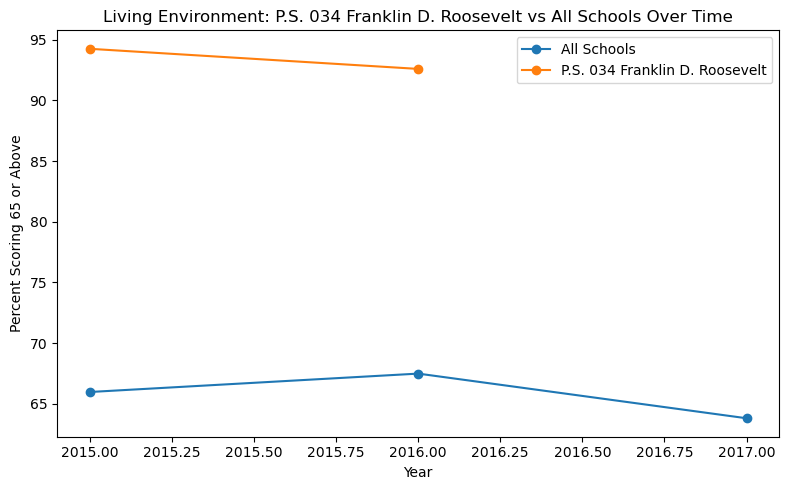

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["Year"], comparison_df["Dataset Average"], marker="o", label="All Schools")
plt.plot(comparison_df["Year"], comparison_df["School Average"], marker="o", label=school_name)

plt.xlabel("Year")
plt.ylabel("Percent Scoring 65 or Above")
plt.title(f"{exam_name}: {school_name} vs All Schools Over Time")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
if school_avg > dataset_avg:
    conclusion = (
        f"{school_name} performed above the overall dataset average in {exam_name} "
        f"based on {score_col}. This suggests the school’s student performance on this exam "
        f"was relatively stronger than the broader group of schools."
    )
else:
    conclusion = (
        f"{school_name} performed below the overall dataset average in {exam_name} "
        f"based on {score_col}. This suggests the school may have room for improvement "
        f"relative to the broader group of schools."
    )

print(conclusion)

P.S. 034 Franklin D. Roosevelt performed above the overall dataset average in Living Environment based on Percent Scoring 65 or Above. This suggests the school’s student performance on this exam was relatively stronger than the broader group of schools.
